# **Linear Regression from Scratch**

Students often encounter linear regression for the first time when they are asked to find the line that *fits* a given set of data points well. The intercept and slope are calculated, and, depending on the objective, the result of the regression is evaluated using some measure of deviation. This deviation is then reported, and from there, the question of whether the regression served its purpose is assessed. The lesson often stops there. For some people, this is sufficient.

However, this mathematical tool offers much more than that. As a student of forecasting and causal inference, I was made painfully aware of the "unreasonable effectiveness of linear regression," as Matheus Facure put it. It is difficult to overlook.

This notebook is an attempt to introduce linear regression together with some statistical concepts that may otherwise be neglected when the sole purpose is to find the *line of best fit*. Rather than treating regression as merely a method for drawing a line through a collection of points, we will explore what the fitted coefficients actually mean, how uncertain our estimates are, and how we can determine whether the patterns we observe are distinguishable from what might arise by chance.

## **Simple Linear Regression**

### **Key equations**

Assume that a collection of measurements $\{(X_i,Y_i)\}_{i=1}^N$ is linearly related:

\begin{align*}
Y_i &= \beta_0 + \beta_1 X_i + \epsilon_i.
\end{align*}

There is an **error** term $\epsilon_i$, which can be understood by first assuming that the *expectation value* of the error term given $X_i$ is 0. Mathematically, $\mathbb{E}[\epsilon_i | X_i] = 0$. This implies that the expectation value of $Y_i$ given $X_i$ is

$$\mathbb{E}[Y_i|X_i] = \beta_0 + \beta_1 X_i.$$

We can therefore interpret the error as the deviation of the population $Y_i$ from its expected value given $X_i$, or $\epsilon_i=Y_i-\mathbb{E}[Y_i|X_i]$. Here, $\beta_0$ and $\beta_1$ are the *true* parameters. They specify the linear relationship between $X$ and the conditional mean of $Y$. It is important to understand early on that we cannot fully know what these parameters actually are, unless we have access to the full **population**, which in principle, we have not. Our pursuit is to find the best *estimates* of these parameters, $\{\hat\beta_0, \hat\beta_1\}$, which we can calculate from the **samples** of the population. Readers familiar with the works of Plato might want to think about the true parameters as Platonic ideals, existing in a realm beyond our conception, and our estimates as mere approximations of these perfect objects. To characterize how the observed data deviates from our fitted line, we define the **residuals** as

$$e_i = Y_i-\hat Y_i=Y_i-\hat\beta_0-\hat\beta_1 X_i.$$

The distinction between the error and the residual is subtle. The model error is unobservable since it is defined with respect to the true population regression parameters. The residual is defined with respect to the fitted sample regression line. They coincide for all observations if and only if $\hat\beta_0=\beta_0$ and $\hat\beta_1=\beta_1$, provided that the predictor values are not all identical. We can minimize functions of the residuals but not the error precisely because we do not have access to the entire population. The minimization process is often defined with respect to the sum of squared residuals.

\begin{align*}
\alpha(\hat\beta_0,\hat\beta_1) &= \sum_{i=1}^N(Y_i-\hat\beta_0-\hat\beta_1 X_i)^2.
\end{align*}

This is one among many metrics that can be used as a basis for minimization. The optimal parameters with respect to the sum of squared residuals constitute the heart of **ordinary least squares (OLS) regression**. Any stationary point of a convex objective function such as ours is a global minimum.

\begin{align*}
\frac{\partial\alpha}{\partial\hat\beta_0}
&= -2\sum_{i=1}^N(Y_i-\hat\beta_0-\hat\beta_1 X_i)=0,\\
\frac{\partial\alpha}{\partial\hat\beta_1}
&= -2\sum_{i=1}^N X_i(Y_i-\hat\beta_0-\hat\beta_1 X_i)=0.
\end{align*}

The above conditions translate to the following equalities:

\begin{align*}
\hat\beta_0 N+\hat\beta_1\sum_{i=1}^N X_i&=\sum_{i=1}^N Y_i,\\
\hat\beta_0\sum_{i=1}^N X_i+\hat\beta_1\sum_{i=1}^N X_i^2&=\sum_{i=1}^N X_iY_i.
\end{align*}

Before we proceed, we define the dataset mean, variance, and covariance, respectively:

\begin{align*}
\bar{X}&=\frac{1}{N}\sum_{i=1}^N X_i,\\
\bar{Y}&=\frac{1}{N}\sum_{i=1}^N Y_i,\\
\text{Var}(\mathbf{X})&=\frac{1}{N}\sum_{i=1}^N(X_i-\bar{X})^2,\\
&=\frac{1}{N}\sum_{i=1}^N X_i^2-\bar{X}^2,\\
\text{Cov}(\mathbf{X}, \mathbf{Y})&=\frac{1}{N}\sum_{i=1}^N(X_i-\bar{X})(Y_i-\bar{Y}),\\
&=\frac{1}{N}\sum_{i=1}^N X_iY_i -\bar{X}\bar{Y}
\end{align*}

This allows us to write the sums of $X_i$ and $Y_i$ in terms of their means, the sums of squares in terms of the variance, and the cross terms in terms of the covariance.

\begin{align*}
N\hat\beta_0+N\hat\beta_1\bar{X}&=N\bar{Y},\\
N\hat\beta_0\bar{X}+N\hat\beta_1(\text{Var}(\mathbf{X})+\bar{X}^2)&=N(\text{Cov}(\mathbf{X}, \mathbf{Y})+\bar{X}\bar{Y}).
\end{align*}

We can now solve the system of equations using standard matrix methods. We write the equation as follows:

\begin{align*}
\begin{bmatrix}
1 & \bar{X}\\
\bar{X} & \text{Var}(\mathbf{X})+\bar{X}^2
\end{bmatrix}
\begin{bmatrix}
\hat\beta_0\\
\hat\beta_1
\end{bmatrix}
&=
\begin{bmatrix}
\bar{Y}\\
\text{Cov}(\mathbf{X}, \mathbf{Y})+\bar{X}\bar{Y}
\end{bmatrix}.
\end{align*}

The matrix is invertible only if $\text{Var}(\mathbf{X})>0$. By definition, the variance cannot be negative. For it to be zero, however, it requires all $X_i=\bar X$. As long as our predictors are not collapsed to a single point, we will have no problem. Keeping this in mind, we can now invert the square matrix:

\begin{align*}
\begin{bmatrix}
\hat\beta_0\\
\hat\beta_1
\end{bmatrix}
&=
\frac{1}{\text{Var}(\mathbf{X})}
\begin{bmatrix}
\text{Var}(\mathbf{X}) + \bar{X}^2& -\bar{X}\\
-\bar{X} & 1
\end{bmatrix}
\begin{bmatrix}
\bar{Y}\\
\text{Cov}(\mathbf{X}, \mathbf{Y})+\bar{X}\bar{Y}
\end{bmatrix}.
\end{align*} 
 
Finally, we explicitly write the set of parameters that minimizes the sum of squared residuals:

\begin{align*}
\hat\beta_0
&=\frac{\bar{Y}\,\text{Var}(\mathbf{X})-\bar{X}\,\text{Cov}(\mathbf{X}, \mathbf{Y})}
{\text{Var}(\mathbf{X})},\\
\hat\beta_1
&=\frac{\text{Cov}(\mathbf{X}, \mathbf{Y})}
{\text{Var}(\mathbf{X})}.
\end{align*}

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import statsmodels.formula.api as smf

from numpy.linalg import inv

In [2]:
def slr_fit(x_obs, y_obs):

    x_obs = np.array(x_obs)
    y_obs = np.array(y_obs)
    
    cov = np.cov(x_obs, y_obs, ddof = 1)[0, 1]
    var = np.var(x_obs, ddof = 1)
    slope = cov / var
    y_int = np.mean(y_obs) - np.mean(x_obs) * slope

    params = np.array([y_int, slope])
    y_fit = y_int + slope*x_obs

    return y_fit, params

To test the above method, we generate a synthetic data defined by the relation

\begin{align*}
Y_i = \frac{1}{4}X_i + \epsilon_i
\end{align*}

where $\epsilon$ is a random variable taken from the normal distribution with mean $0$ and standard deviation of $5/2$.

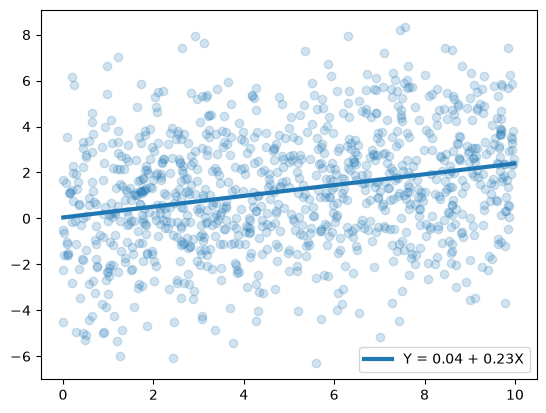

In [3]:
rng = np.random.default_rng(67)

n_vals = 10**3
x_min = 0
x_max = 10
std_samp = 5/2
theo_slope = 1/4

x_arr = np.sort(rng.uniform(x_min, x_max, n_vals))
y_arr = theo_slope*x_arr 
y_obs = rng.normal(y_arr, std_samp, n_vals)

y_fit, params = slr_fit(x_arr, y_obs)

plt.scatter(x_arr, y_obs, alpha = 0.2)
plt.plot(x_arr, y_fit, lw = 3, label = f'Y = {params[0]:.2f} + {params[1]:.2f}X')
plt.legend()
plt.show()

### **Confidence interval**

We might think that since we have obtained slope and intercept estimates close to the values we used to generate our data, we can already pat ourselves on the back for a job well done. But this is cheating. We knew the data-generating process, and therefore we knew what the true parameters were supposed to be. Think instead about the case where the data-generating process is completely unknown to us. We only have the cold dataset, which we cannot really interrogate. If we were to repeatedly sample from the underlying population, how much would our estimates change from sample to sample? In other words, how reliable are our estimates? Because relying solely on point estimates to draw conclusions is not only reckless but also dangerous.

Ideally, we would answer this by repeatedly collecting new samples from the population, fitting our model to each sample, and looking at how the resulting estimates vary. This would give us the **sampling distribution** of our estimator. The problem, of course, is that we usually do not have the luxury of repeatedly sampling from the population. We may have only one dataset, and the population distribution is unknown to us.

This is where the **bootstrap** comes in. The basic idea is deceptively simple: we treat the data we actually observed as a stand-in for the unknown population. The empirical distribution of our observed data gives every observed data pair a probability of $1/n$. We then repeatedly sample from this empirical distribution, with replacement, creating many new datasets that resemble the original dataset but are not identical to it. By fitting our model to each of these bootstrap datasets, we can see how much our estimated parameters vary. In this way, the bootstrap gives us an approximation to the sampling distribution of our estimator without having to repeatedly sample from the actual population. Think of it as a simulation of repeated experiments. We do not know how the population would vary across repeated samples, so we use the variation contained in our observed sample to imitate that process.

To address this, we use a **95% bootstrap percentile interval**, which is a specific type of $95\%$ confidence interval (CI). Our $95\%$ CI is a random interval produced by a procedure that contains the true parameter approximately $95\%$ of the time in repeated sampling. The true parameter stays fixed. It is the interval that varies from sample to sample and contains the true parameter approximately $95\%$ of the time.

We will use a *pairwise bootstrap method* to construct our CI. Since we are fitting a regression model, we resample the $(X_i,Y_i)$ pairs together. This is important because the relationship between $X$ and $Y$ is part of the data we are trying to preserve. We then fit the same OLS model to every bootstrap sample and record the resulting estimates $\hat\beta_0^*$ and $\hat\beta_1^*$. After doing this many times, the collection of bootstrap estimates forms an approximation to the sampling distributions of the intercept and slope.

The method is as follows:

1. Draw an index $i$ from the $n$ observed data pairs $(X_i,Y_i)$, record the corresponding pair, and then replace it. Because we sample with replacement, the same observation may be selected multiple times while other observations may not be selected at all.
2. Repeat this $n$ times, producing a bootstrap dataset ${(X_i^*,Y_i^*)}_{i=1}^n$ of the same size as the original dataset.
3. Fit the OLS model to the $n$ resampled pairs and record the estimated parameters $\hat\beta_0^*$ and $\hat\beta_1^*$.
4. Repeat steps 1-3 $R$ times, giving $\{(\hat\beta_0^*,\hat\beta_1^*)\}_{r=1}^R$. This collection is our approximation to the sampling distribution of the estimators.
5. Find the $2.5^{\text{th}}$ and $97.5^{\text{th}}$ percentiles of the bootstrap estimates: $[q_{0.025},q_{0.975}].$


In [4]:
def slr_ci(x_obs, y_obs, r_iter = 10**4, verbose = True):

    rng = np.random.default_rng(67)

    x_obs = np.array(x_obs)
    y_obs = np.array(y_obs)
    
    n_vals = len(x_obs)
    bootstrap_params = np.empty((r_iter, 2))

    for i in range(r_iter):
        indices = rng.choice(n_vals, n_vals, replace = True)
        _ , bootstrap_params[i] = slr_fit(x_obs[indices], y_obs[indices])

    bs_int = bootstrap_params[:, 0]
    bs_slope = bootstrap_params[:, 1]

    ci_int = np.percentile(bs_int, [2.5, 97.5])
    ci_slope = np.percentile(bs_slope, [2.5, 97.5])

    if verbose:
        print(f'The estimated 95% CI is {ci_int} for the intercept and {ci_slope} for the slope.') 

    return ci_int, ci_slope

In [5]:
ci_int, ci_slope = slr_ci(x_obs = x_arr, y_obs = y_obs, verbose = True)

The estimated 95% CI is [-0.27005861  0.35612204] for the intercept and [0.18122285 0.2879466 ] for the slope.


It is important to stress that reporting a confidence interval is often more informative than reporting a point estimate alone for two reasons. First, it acknowledges that our estimate is subject to sampling uncertainty and that factors not captured by our model can affect the observed data. Second, the interval provides a range of plausible values for the parameter under the chosen confidence-interval procedure, allowing us to account for uncertainty when making decisions or preparing for different possible scenarios.

### **Hypothesis testing**

We can now ask a more specific question: is the association we observe between $X$ and $Y$ sufficiently strong that it would be unusual to obtain such a slope if there were actually no association between the two variables? Our confidence interval already gives us some information about this. If the interval excludes $0$, then $0$ is not among the parameter values contained within the interval under the chosen confidence-interval procedure. This suggests that a zero slope is inconsistent with the range of values supported by our interval. However, the confidence interval and the hypothesis test are answering slightly different questions, so we will examine the question directly using a **permutation test**.

The idea is to construct a reference distribution for our slope under a null hypothesis in which there is no association between $X$ and $Y$. We begin with the data we actually observed and then randomly shuffle the $Y$ values while leaving the $X$ values fixed. This destroys the original pairing between $X$ and $Y$. If there was a genuine association between them, that association should disappear when the pairing is randomly rearranged. What remains is the kind of slope we might obtain purely from chance when there is no association.

This is the key idea behind the permutation test: rather than trying to simulate repeated samples from the population, as we did with the bootstrap, we simulate what our data would look like **under the null hypothesis**. We then ask whether our observed slope looks unusual relative to this null distribution. Permuting $Y$ relative to $X$ is appropriate when the null hypothesis implies that the observations are exchangeable under this permutation. In this simple setting, the procedure provides a reference distribution for the slope under the null hypothesis of **no association** ($H_0: X\perp Y$). In other words, if there are no sort of relation **at all**, be it linear or not. We then construct the *null distribution* of our chosen statistic and use it to compare against our observed result. The method is as follows:

1. Fit the OLS model to the original dataset and record the observed slope $\hat\beta_1$.
2. Randomly permute the $Y_i$ values and pair them with the corresponding $X_i$ values. The original relationship between the observations is therefore broken while the individual $X$ and $Y$ values themselves are preserved.
3. Fit the OLS model to the permuted dataset and record the resulting slope $\hat\beta_1^*$.
4. Repeat the previous steps $R$ times, producing $\{\hat\beta_1^*\}_{r=1}^R$. This collection of slopes forms our approximation to the **null distribution** of the slope.
5. Compare the observed slope to this null distribution. For a two-sided test, we count the number of permuted slopes that are at least as extreme as the observed slope, i.e., satisfying
   $$|\hat\beta_1^*| \geq |\hat\beta_1|.$$

The proportion of permutations at least as extreme as our observed result gives us an estimate of the probability of obtaining a result this extreme under the null hypothesis. We will report the Monte Carlo $p$-value

$$
p=\frac{k+1}{R+1},
$$

where $k$ is the number of permuted statistics satisfying $|\hat\beta_1^*| \geq |\hat\beta_1|$. When $k=0$, the Monte Carlo $p$-value is the smallest resolvable value for a chosen $R$.

A small $p$-value is evidence against the null hypothesis because it means that slopes as extreme as the one we observed are rarely produced when the $X$ and $Y$ pairings are randomized. A large $p$-value does not automatically mean that the alternative hypothesis, $H_1: X\not\perp Y$, is true. It simply means that we do not have sufficient evidence to reject the null hypothesis based on this test.


In [6]:
def slr_pval(x_obs, y_obs, r_iter = 10**4):

    rng = np.random.default_rng(67)

    x_obs = np.array(x_obs)
    y_obs = np.array(y_obs)
    
    n_vals = len(x_obs)
    permtest_slope = np.empty(r_iter)
    _, params = slr_fit(x_obs, y_obs)
    init_slope = params[1]

    for i in range(r_iter):
        indices = rng.choice(n_vals, n_vals, replace = False)
        _, params = slr_fit(x_obs, y_obs[indices])
        permtest_slope[i] = params[1]

    count = np.sum(np.abs(permtest_slope) >= np.abs(init_slope))
    pval = (count + 1)/(r_iter + 1)  # monte carlo correction

    return pval

In [7]:
pval = slr_pval(x_obs = x_arr, y_obs = y_obs)
print(f'The p-value is {pval:.4f}')

The p-value is 0.0001


### **Coefficient of determination**

A cautious student may perform all the calculations above and still be left unconvinced. While it is true that there is a statistically significant trend, and we know the possible wiggle room of the parameters based on the uncertainty inherent in our methods, this does not tell us anything about the explanatory power of regression on the given data. Let $\bar Y$ denote the sample mean of $Y$. Suppose we want to describe the variation of the observed data in terms of the variation of the fitted data and the residuals.

\begin{align*}
\sum_{i}(Y_i-\bar Y)^2&=\sum_{i}(Y_i-\hat Y_i+\hat Y_i-\bar Y)^2,\\
&=\sum_{i}(Y_i-\hat Y_i)^2+\sum_{i}(\hat Y_i-\bar Y)^2+2\sum_{i}(Y_i-\hat Y_i)(\hat Y_i-\bar Y)
\end{align*}

Note that each factor in the cross-product term can be rewritten in the following way:

\begin{align*}
Y_i-\hat Y_i&=Y_i-\bar Y +\bar Y-\hat Y_i\\
&=(Y_i-\bar Y) +\hat\beta_0 + \hat\beta_1 \bar X -\hat\beta_0 - \hat\beta_1 X_i\\
&=(Y_i-\bar Y) - \hat\beta_1 (X_i - \bar X)\\
\hat Y_i -\bar Y &= \hat\beta_0 + \hat\beta_1 X_i -\hat\beta_0 -\hat\beta_1 \bar X\\
&= \hat\beta_1 (X_i - \bar X)
\end{align*}

Putting them together makes the simplification apparent.

\begin{align*}
\sum_{i}(Y_i-\hat Y_i)(\hat Y_i-\bar Y)&=\hat\beta_1\sum_{i} \left[(X_i - \bar X)(Y_i-\bar Y)  - \hat\beta_1 (X_i - \bar X)^2\right],\\
&=\hat\beta_1\sum_{i} \left[(X_i - \bar X)(Y_i-\bar Y)  - \frac{\sum_j (X_j-\bar X)(Y_j-\bar Y)}{\sum_j (X_j-\bar X)^2} (X_i - \bar X)^2\right]\\
&=\hat\beta_1\left[\sum_{i} (X_i - \bar X)(Y_i-\bar Y)  - \sum_j(X_j-\bar X)(Y_j-\bar Y)\right]\\
&=0
\end{align*}

Therefore, we can decompose the variation of the observed data cleanly:

\begin{align*}
\sum_{i}(Y_i-\bar Y)^2&=\sum_{i}(Y_i-\hat Y_i)^2+\sum_{i}(\hat Y_i-\bar Y)^2.
\end{align*}

This neat decomposition can be unpacked. The left-hand side is the **Total Sum of Squares (TSS)** term, which, as previously mentioned, describes the total variation in the observed data. The first term on the right-hand side should be familiar to us, since it is the **Residual Sum of Squares (RSS)**, which was the basis for the ordinary least squares method we used to obtain the regression parameters. This measures the total amount of variation in the values that the model fails to explain. The last term is the **Explained Sum of Squares (ESS)**, whose name is instructive, as it measures the total amount of variation explained by the model. If the model can fully explain the variation in the data, then $\text{RSS}=0$ and, equivalently, $\text{TSS}=\text{ESS}$. But the absolute magnitudes of these quantities might be difficult to interpret in isolation, since they depend on the scale of the data. It is more informative to look at their ratios. More specifically, we ask: *how much of the variation in the observed data can be explained by the model?* The scale-independent answer to this question is captured by the $R^2$ value:

\begin{align*}
R^2&=\frac{\text{ESS}}{\text{TSS}}=1-\frac{\text{RSS}}{\text{TSS}}
\end{align*}

By definition, $R^2\in[0,1]$ for an OLS model with an intercept evaluated on the same data used for fitting. A high $R^2$ means that the model explains a large proportion of the variation in the data. Conversely, a low $R^2$ means that the model explains relatively little of the variation.

In [8]:
def slr_diag(x_obs, y_obs):

    y_fit, _ = slr_fit(x_obs, y_obs)
    y_mean = np.mean(y_fit)

    tss = (y_obs - y_mean).T @ (y_obs - y_mean)
    rss = (y_obs - y_fit).T @ (y_obs - y_fit) 
    ess = (y_fit - y_mean).T @ (y_fit - y_mean) 

    return {'TSS': tss, 'RSS': rss, 'ESS': ess, 'R2': ess/tss}

In [9]:
print([slr_diag(x_arr, y_obs)])

[{'TSS': np.float64(6704.559246009656), 'RSS': np.float64(6241.11611284542), 'ESS': np.float64(463.4431331642367), 'R2': np.float64(0.06912357936728855)}]


There $R^2$ score of the data is low. Does it mean that our discussion above is meaningless? **No**. The $R^2$ score merely addresses a different question. The confidence interval and the $p$ value establishes that there is a statistically significant trend. The $R^2$ score tells us that, while there is a trend, the regression line simply cannot explain much of the variation in the data.

## **Multiple Linear Regression**

### **Derivation**

Suppose we have $m$ observations with $n$ predictors. We can write the relationship in vectorized form as

\begin{align*}
\mathbf{Y}&=\mathbf{X}\bm{\beta}+\bm{\epsilon}.
\end{align*}

Here $\mathbf{Y}$ and $\bm{\epsilon}$ are vectors with $m$ entries, while $\bm{\beta}$ is a vector with $n+1$ entries, corresponding to the intercept and the $n$ predictors. One might wonder how the intercept term is accounted for. To do this, we construct the **design matrix**, $\mathbf{X}$, such that its first column is a column of ones and its remaining columns represent the separate predictors. Hence, $\mathbf{X}$ is an $m\times(n+1)$ matrix. We want to determine $\bm{\hat\beta}$ such that the sum of squared residuals

\begin{align*}
\alpha=(\mathbf{Y}-\mathbf{X}\bm{\hat\beta})^T(\mathbf{Y}-\mathbf{X}\bm{\hat\beta})
\end{align*}

is minimized. To achieve this, we will use the Einstein summation convention to make the calculations easier. In a nutshell, we express vectors and matrices in terms of their elements, with indices appearing once being free indices, while indices appearing twice are implicitly summed over. We take the derivative with respect to each $\hat\beta_k$:

\begin{align*}
\frac{\partial\alpha}{\partial\hat\beta_k}
&=-2X_{ik}(Y_i-X_{ij}\hat\beta_j)=0.
\end{align*}

This condition reduces to the **normal equations**:

\begin{align*}
X_{ik}Y_i&=X_{ik}X_{ij}\hat\beta_j.
\end{align*}

Since $k$ is a free index, this gives a system of $n+1$ equations. In vector notation,

\begin{align*}
\mathbf{X}^T\mathbf{Y}&=\mathbf{X}^T\mathbf{X}\bm{\hat\beta}.
\end{align*}

Finally, assuming $\mathbf{X}^T\mathbf{X}$ is invertible,

\begin{align*}
\bm{\hat\beta}&=(\mathbf{X}^T\mathbf{X})^{-1}\mathbf{X}^T\mathbf{Y}.
\end{align*}

This quantity is called the **least squares estimator**. Before observing the data, it is a random variable because it is a function of the random sample. How sure are we that the least squares estimator is really estimating $\bm\beta$?

\begin{align*}
\bm{\hat\beta}
&=(\mathbf{X}^T\mathbf{X})^{-1}\mathbf{X}^T(\mathbf X\bm\beta +\bm\epsilon)\\
&=\bm\beta + (\mathbf{X}^T\mathbf{X})^{-1}\mathbf{X}^T\bm\epsilon.
\end{align*}

Unlike the estimator, $\bm\beta$ is a fixed parameter. It has a defined value. Under repeated sampling, the realized data, and hence the realized value of $\bm{\hat\beta}$, can differ from sample to sample. If we take the expectation of $\bm{\hat\beta}$ and, just as in the univariate case, assume that $\mathbb{E}[\bm\epsilon|\mathbf X]=0$, then

\begin{align*}
\mathbb{E}[\bm{\hat\beta}|\mathbf X]
&=\bm\beta.
\end{align*}

In other words, conditional on $\mathbf X$, the least squares estimator is **unbiased** for $\bm\beta$. If we were to repeatedly sample from the same data-generating process, the average of the resulting estimates would approach the true $\bm\beta$.

### **Residuals**
Using the expression for $\bm{\hat\beta}$, we can write the vector of residuals as

\begin{align*}
\mathbf e
&=[\mathbf I-\mathbf X(\mathbf{X}^T\mathbf{X})^{-1}\mathbf{X}^T]\mathbf{Y}.
\end{align*}

Defining $\mathbf P \equiv \mathbf X(\mathbf{X}^T\mathbf{X})^{-1}\mathbf{X}^T$ and $\mathbf M\equiv \mathbf I-\mathbf P$, we can rewrite the residuals as $\mathbf e=\mathbf{M}\mathbf{Y}$. We can interpret $\mathbf M$ as a matrix that *residualizes* $\mathbf Y$; it removes from $\mathbf{Y}$ the components explained by $\mathbf{X}$. As an exercise, you can verify that $\mathbf P$ is symmetric $(\mathbf P^T=\mathbf P)$ and idempotent $(\mathbf P^2=\mathbf P)$, and by extension, $\mathbf M$ inherits the same properties.

The matrix $\mathbf P$ is called the **projection matrix** since it *projects* the observed response vector $\mathbf{Y}$ onto the subspace determined by the columns of the design matrix. In general, $\mathbf P$ is **not invertible**, as we will now demonstrate. Assume that $\mathbf P$ is non-singular.

\begin{align*}
\mathbf P^2 &= \mathbf P,\\
\mathbf P^{-1}\mathbf P^2 &= \mathbf P^{-1}\mathbf P,\\
\mathbf P &= \mathbf I.
\end{align*}

Therefore, the projection matrix is invertible, i.e., $\mathbf P^{-1}$ exists, if and only if $\mathbf P=\mathbf I$. As a final note for this section, we will establish this geometric fact: **the residual is orthogonal to every column of the design matrix**. Observe that

\begin{align*}
\mathbf X^T \mathbf e
&=[\mathbf X^T-\mathbf X^T\mathbf X(\mathbf{X}^T\mathbf{X})^{-1}\mathbf{X}^T]\mathbf{Y},\\
&=[\mathbf X^T-\mathbf X^T]\mathbf{Y},\\
&=0.
\end{align*}

### **Application: Advertising Data**

The `advertising` dataset that will be used in the following analysis was obtained [here](https://trevorhastie.github.io/ISLR/data.html). We assume that the data is **not randomized**. Furthermore, there are no additional information given by the dataset beyond the given expenditures, so we have no strong basis to provide causal claims. This needs to be said because **association does not imply causation**. 

In [10]:
ad = pd.read_csv('advertising.csv', index_col = 0).reset_index(drop = True)
ad.head()

,TV,radio,newspaper,sales
0,230.1,37.8,69.2,22.1
1,44.5,39.3,45.1,10.4
2,17.2,45.9,69.3,9.3
3,151.5,41.3,58.5,18.5
4,180.8,10.8,58.4,12.9


From our discussion above, it might be tempting to simply do a regression on sales and take their respective coefficients as the coefficients of the multivariate regression. 

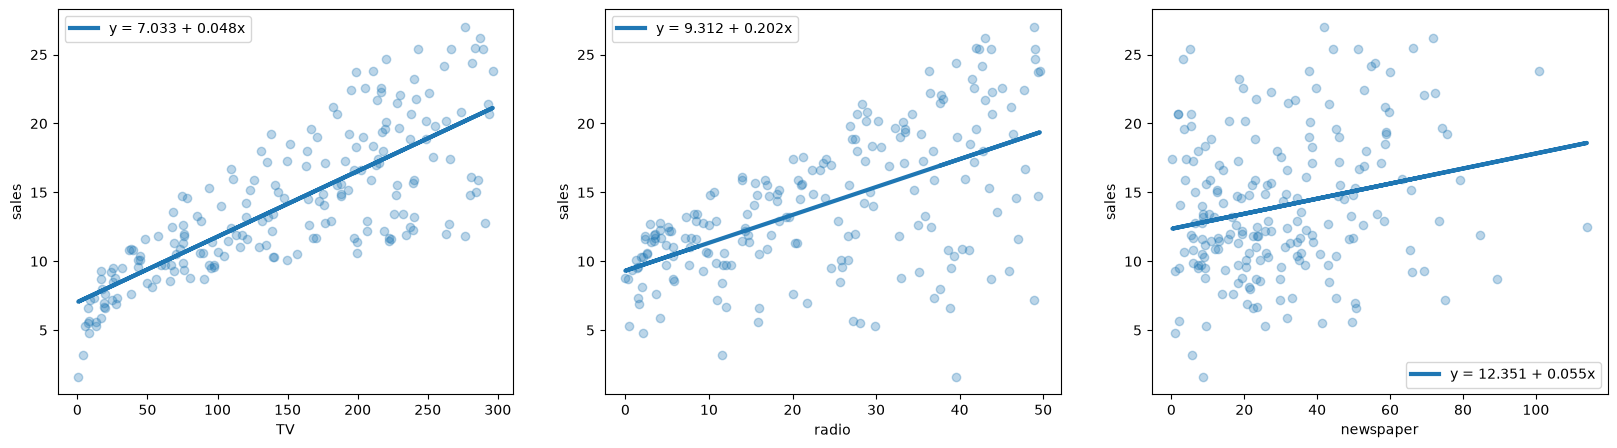

In [11]:
ad_cols = ad.columns.drop('sales')
ad_sales = ad['sales']

fig, ax = plt.subplots(1, 3, figsize = (20, 5))

for i in range(len(ad_cols)):
    ad_col = ad[ad_cols[i]]
    ax[i].scatter(ad_col, ad_sales, alpha = 0.3)
    ax[i].set_xlabel(ad_cols[i])
    ax[i].set_ylabel('sales')
    
    sales_pred, sales_params = slr_fit(ad_col, ad_sales)
    ax[i].plot(ad_col, sales_pred, lw = 3, label = f'y = {sales_params[0]:.3f} + {sales_params[1]:.3f}x')
    ax[i].legend()

plt.show()

This is a correct answer for a different question. This is only valid **if** we want to do a simple bivariate analysis between each expenditure form and sales. However, if the goal is to construct the coefficient of the multivariate regression model, this is **incorrect**. The relation of sales and a specific advertising method is distorted by the presence of other methods. The proper way to do this is to use the matrix expression for $\hat{\bm\beta}$. 

In [12]:
def mlr_fit(features, target, include_intercept = True):

    n_vals = len(target)
    n_ones = np.ones(n_vals)

    if include_intercept:
        design_mat = np.column_stack((n_ones, features))
    else:
        design_mat = features

    beta_vals = inv(design_mat.T @ design_mat) @ design_mat.T @ target
    fit = design_mat @ beta_vals

    return fit, beta_vals

In [13]:
data = ad
targ_col = 'sales'

print(f'The regression coefficients are {mlr_fit(features = data[data.columns.drop(targ_col)], target = data[targ_col])[1]}')

The regression coefficients are [ 2.93888937e+00  4.57646455e-02  1.88530017e-01 -1.03749304e-03]


Similar to what we discussed above, it is important to put confidence intervals around our estimates. The procedure of constructing the interval is similar to the univariate case.

In [14]:
def mlr_ci(features, target, r_iter = 10**4):

    rng = np.random.default_rng(67)

    n_rows = len(target)
    _, n_params = features.shape
    bootstrap_params = np.empty((r_iter, n_params + 1))

    for i in range(r_iter):
        indices = rng.choice(n_rows, n_rows, replace = True)
        _, bootstrap_params[i] = mlr_fit(features = features.iloc[indices], target = target.iloc[indices])

    ci_vals = [np.percentile(bootstrap_params[:, i], [2.5, 97.5]) for i in range(n_params + 1)]

    return np.array(ci_vals)

In [15]:
mlr_ci(features = data[data.columns.drop(targ_col)], target = data[targ_col])

array([[ 2.26274301,  3.57559015],
       [ 0.04190396,  0.04948053],
       [ 0.16675607,  0.20965765],
       [-0.01338282,  0.01187899]])

The results for the newspaper advertising is interesting for two reasons: its regression coefficient was found to be negative, and that the confidence interval includes $0$. It is difficult to provide an interpretation for the coefficients yet since our expression for $\hat\beta$ is lumped through $\mathbf X$ and $\mathbf Y$. Difficult does not mean impossible, as we will see in the next section.

<!-- It is interesting that the final $95\% \text{CI}$ corresponding to newspaper advertising includes $0$. Our confidence-interval procedure provides support that $0$ is among the plausible regression coefficient of newspaper advertising. It is likely that  -->

### **Frisch-Waugh-Lovell result**

Let us split the predictor matrix by isolating the predictor of interest as a vector:

\begin{align*}
\mathbf{Y} &= \mathbf{u}\beta_1+\mathbf{X}\bm{\beta}_2+\bm{\epsilon}.
\end{align*}

Here, $\mathbf{u}$ contains the predictor whose coefficient we are interested in, while $\mathbf{X}$ contains all the other *nuisance* predictors, including the intercept. The normal equations from multivariate linear regression are

\begin{align*}
\mathbf{X}^T\mathbf{Y}&=\mathbf{X}^T\mathbf{X}\bm{\hat\beta}.
\end{align*}

Writing this in terms of $\mathbf{u}$ and $\mathbf{X}$ gives

\begin{align*}
\mathbf{u}^T\mathbf{Y}
&=\mathbf{u}^T\mathbf{u}\hat\beta_1+\mathbf{u}^T\mathbf{X}\bm{\hat\beta}_2,\\
\mathbf{X}^T\mathbf{Y}
&=\mathbf{X}^T\mathbf{u}\hat\beta_1+\mathbf{X}^T\mathbf{X}\bm{\hat\beta}_2.
\end{align*}

We can solve the second equation for $\bm{\hat\beta}_2$:

\begin{align*}
\bm{\hat\beta}_2
&=(\mathbf{X}^T\mathbf{X})^{-1}
\mathbf{X}^T(\mathbf{Y}-\mathbf{u}\hat\beta_1).
\end{align*}

Substituting this into the first equation gives

\begin{align*}
\mathbf{u}^T\mathbf{Y}
&=\mathbf{u}^T\mathbf{u}\hat\beta_1
+\mathbf{u}^T\mathbf{X}
(\mathbf{X}^T\mathbf{X})^{-1}
\mathbf{X}^T(\mathbf{Y}-\mathbf{u}\hat\beta_1).
\end{align*}

Using the *annihilator* $\mathbf{M}$, we can write this equation as

\begin{align*}
\mathbf{u}^T\mathbf{M}\mathbf{Y}
&=\mathbf{u}^T\mathbf{M}\mathbf{u}\hat\beta_1.
\end{align*}

Therefore,

\begin{align*}
\hat\beta_1
&=(\mathbf{u}^T\mathbf{M}\mathbf{u})^{-1}
\mathbf{u}^T\mathbf{M}\mathbf{Y}.
\end{align*}

Since $\mathbf{M}$ is symmetric and idempotent, we have

\begin{align*}
\mathbf{u}^T\mathbf{M}\mathbf{u}
&=(\mathbf{M}\mathbf{u})^T(\mathbf{M}\mathbf{u}),\\
\mathbf{u}^T\mathbf{M}\mathbf{Y}
&=(\mathbf{M}\mathbf{u})^T(\mathbf{M}\mathbf{Y}).
\end{align*}

Thus,

\begin{align*}
\hat\beta_1
&=
\frac{(\mathbf{M}\mathbf{u})^T(\mathbf{M}\mathbf{Y})}
{(\mathbf{M}\mathbf{u})^T(\mathbf{M}\mathbf{u})}
\end{align*}

when $\mathbf{u}$ is a single predictor. If we denote the quantities residualized by $\mathbf{M}$ with a tilde, we can compactly write this as

\begin{align*}
\hat\beta_1
&=
\frac{\tilde{\mathbf{u}}^T\tilde{\mathbf{Y}}}
{\tilde{\mathbf{u}}^T\tilde{\mathbf{u}}}.
\end{align*}

We can push this further by recognizing that we can do this for each predictor:

\begin{align*}
\hat\beta_i
&=
\frac{\tilde{\mathbf{u}}_i^T\tilde{\mathbf{Y}}}
{\tilde{\mathbf{u}}_i^T\tilde{\mathbf{u}}_i}
\end{align*}

where the residualization is performed with respect to the associated nuisance features. For non-intercept coefficients, we can rewrite this as

\begin{align*}
\hat\beta_i
&=
\frac{\text{Cov}(\tilde{\mathbf{u}}_i,\tilde{\mathbf{Y}})}
{\text{Var}(\tilde{\mathbf{u}}_i)}
\end{align*}

which we can recognize from the simple linear regression earlier. This is the Frisch-Waugh-Lovell result: the coefficient of $\mathbf{u}$ from the full multivariate regression is exactly the same as the coefficient obtained by first removing the effects of $\mathbf{X}$ from both $\mathbf{Y}$ and $\mathbf{u}$, and then regressing the residualized $\mathbf{Y}$ on the residualized $\mathbf{u}$. The coefficient $\hat\beta_i$ obtained from this final regression is exactly the same as the coefficient obtained from the original multivariate regression. In other words, $\hat\beta_i$ describes the estimated change in the conditional mean of $\mathbf{Y}$ associated with a unit increase in $\mathbf{u}$, holding all the other predictors *fixed*. To demonstrate, we return to our `advertising` dataset.

In [16]:
def resid_maker(mat):
    n_shape = len(mat)
    return np.identity(n_shape) - np.dot(np.dot(mat, inv(np.dot(mat.T, mat))), mat.T)

def fwl_coeff(features, target, beta_elem):

    y_mat = target
    design_mat = features
    design_mat = np.column_stack((np.ones(len(target)), design_mat))

    u_mat = design_mat[:, beta_elem]
    x_mat = np.delete(design_mat, beta_elem, axis = 1)

    m_mat = resid_maker(x_mat)
    resid_u = m_mat@u_mat
    resid_y = m_mat@y_mat

    return (resid_u@resid_y)/(resid_u@resid_u)

In [17]:
for i in range(len(ad.columns)):
    print(f'beta_{i}: {fwl_coeff(features = data[data.columns.drop(targ_col)], target = data[targ_col], beta_elem = i):.4f}')

beta_0: 2.9389
beta_1: 0.0458
beta_2: 0.1885
beta_3: -0.0010


These are the exact same coefficients obtained from the original procedure. As promised, we will return to the interpretation of the negative regression coefficient for newspaper advertising expenditure. In light of our new conceptual insight, the result points to a negative association between advertising expenditure and sales. Larger newspaper expenditure is associated with lower sales! One might be skeptical of this result since, after all, the coefficient is small. Moreover, if we return to our earlier confidence interval, it actually includes $0$, suggesting that there might be no association at all.

### **Freedman-Lane Procedure** 

We can therefore ask the same question we asked in the simple linear regression case: **if there truly is no relationship between newspaper advertising expenditure and sales, how surprising is our observed coefficient?** The difference is that we are now dealing with a multiple regression model. We cannot simply shuffle the response variable, because doing so would destroy the relationships between the response and all of the other predictors as well. Instead, we want to test the newspaper coefficient while preserving the effects of the other predictors in the model.

This is where the **Freedman-Lane procedure** comes in. The idea is to treat the other predictors as *nuisance predictors*. We first explain as much of the response as possible using these nuisance predictors, leaving behind residual variation. We then randomly permute only this unexplained part and add it back to the fitted values. This gives us new response variables that preserve the structure explained by the nuisance predictors while removing the specific association between the predictor being tested and the remaining variation in the response.

In this sense, the Freedman-Lane procedure extends the logic of our earlier permutation test to multiple regression. Instead of asking whether a coefficient is unusual when **all associations are destroyed**, we ask whether that coefficient is unusual when the effects of the other predictors are retained.

The method is as follows:

1. Fit the full model using the FWL procedure and record the observed coefficient $\hat\beta_i$ for the predictor we want to test.
2. Fit a reduced model containing all nuisance predictors while excluding the predictor whose coefficient $\hat\beta_i$ is being tested. Obtain the fitted values and residuals from this reduced model.
3. Randomly permute the residuals from the reduced model and add them back to the fitted values to construct a **permuted response** $\mathbf{Y}^*$:
   \begin{align*}
   \mathbf{Y}^*
   &=
   \widehat{\mathbf{Y}}_{\text{red}}
   +
   \mathbf{e}_{\text{red}}^*.
   \end{align*}
   Because the fitted values remain unchanged, the relationships between $Y$ and the nuisance predictors are preserved. Only the unexplained part of the response is rearranged.
4. Fit the full model to the permuted response $\mathbf{Y}^*$ and record the corresponding estimated coefficient $\hat\beta_i^*$ for the predictor being tested.
5. Repeat steps 3-4 $r$ times, obtaining
   \begin{align*}
   \{\hat\beta_i^*\}_{r=1}^R.
   \end{align*}
   This collection forms a reference distribution for $\hat\beta_i$ under the null hypothesis that the predictor being tested contributes no additional effect after accounting for the nuisance predictors.
6. Calculate the proportion of $\hat\beta_i^*$ values that are at least as extreme as the observed $\hat\beta_i$, i.e., satisfying
   \begin{align*}
   |\hat\beta_i^*|
   \geq
   |\hat\beta_i|.
   \end{align*}

We again report the Monte Carlo $p$-value.

In [18]:
def fwl_pval(features, target, r_iter = 10**4):

    if not isinstance(features, np.ndarray):
        features = features.to_numpy()

    if not isinstance(target, np.ndarray):
        target = target.to_numpy()
        
    n_vals, n_features = features.shape

    ones = np.ones(n_vals)
    observed_params = np.empty(n_features + 1)
    permuted_params = np.empty((r_iter, n_features + 1))

    for i in range(n_features + 1):

        observed_params[i] = fwl_coeff(features=features, target=target, beta_elem = i)

        nuisance_features = features if i == 0 else np.delete(features, i - 1, axis = 1)
        include_intercept = i != 0
        _, nuisance_params = mlr_fit(features=nuisance_features, target=target, include_intercept = include_intercept)
        nuisance_design = np.column_stack((ones, nuisance_features)) if include_intercept else nuisance_features

        for j in range(r_iter):

            nuisance_resid = target - nuisance_design @ nuisance_params
            permuted_resid = rng.permutation(nuisance_resid)
            permuted_target = nuisance_design @ nuisance_params + permuted_resid
            permuted_params[j, i] = fwl_coeff(features=features, target=permuted_target, beta_elem = i)

    p_vals = np.empty(n_features + 1)

    for i in range(n_features + 1):
        p_vals[i] = (np.sum(np.abs(permuted_params[:, i]) >= np.abs(observed_params[i])) + 1) / (r_iter + 1)

    return p_vals

In [19]:
target = data[targ_col]
features = data[data.columns.drop(targ_col)]

print(f'The p-values for each coefficient are {fwl_pval(features = features, target = target)}')

The p-values for each coefficient are [9.99900010e-05 9.99900010e-05 9.99900010e-05 8.56614339e-01]


The first coefficient, the intercept, is statistically significant. If we strip our business off of any advertising treatment, the model predicts that the expected value of sales are unlikely to be zero. The p-value of the second and third coefficients imply that the TV and radio advertising have statistically significant relations with sales. The test, however, is two-sided, so we only have evidence to rule out that these advertising media have non-zero coefficient values. For the newspaper advertising, however, it has a p-value of $0.86$! If there truly is no relation between the newspaper treatment and sales, then the obtained regression coefficient is not that extreme. It is not unusual assuming that the distribution is null. The data do not provide strong evidence against the null hypothesis that the regression coefficient of newspaper advertising is zero.

### **Coefficient of determination, again**

We can also assess the explanatory power of our model through the sum-of-squares decomposition, but now in vector form. Let $\mathbf{\bar Y}$ denote a vector whose components are all equal to the mean value of $\mathbf Y$. We decompose the TSS as follows:

\begin{align*}
(\mathbf{Y}-\mathbf{\bar Y})^T(\mathbf{Y}-\mathbf{\bar Y})
&=(\mathbf{Y}-\mathbf{\hat Y}+\mathbf{\hat Y}-\mathbf{\bar Y})^T(\mathbf{Y}-\mathbf{\hat Y}+\mathbf{\hat Y}-\mathbf{\bar Y})\\
&=(\mathbf{Y}-\mathbf{\hat Y})^T(\mathbf{Y}-\mathbf{\hat Y})
+(\mathbf{\hat Y}-\mathbf{\bar Y})^T(\mathbf{\hat Y}-\mathbf{\bar Y})
+2(\mathbf{Y}-\mathbf{\hat Y})^T(\mathbf{\hat Y}-\mathbf{\bar Y}).
\end{align*}

We see that this should be the usual decomposition $\text{TSS}=\text{RSS}+\text{ESS}$ except for the final cross term. Our intuition tells us that this should somehow reduce to zero. Decomposing this term further:

\begin{align*}
(\mathbf{Y}-\mathbf{\hat Y})^T(\mathbf{\hat Y}-\mathbf{\bar Y})
&=(\mathbf{Y}^T\mathbf{\hat Y}-\mathbf{\hat Y}^T\mathbf{\hat Y})
+(\mathbf{\hat Y}^T\mathbf{\bar Y}-\mathbf{Y}^T\mathbf{\bar Y}).
\end{align*}

The first term is zero, and we can see this by rewriting $\mathbf{\hat Y}$ in terms of the projection matrix, $\mathbf P$, which is symmetric and idempotent:

\begin{align*}
\mathbf{\hat Y}^T\mathbf{\hat Y}
&=(\mathbf{P}\mathbf{Y})^T(\mathbf{P}\mathbf{Y})\\
&=\mathbf{Y}^T\mathbf{P}^T\mathbf{P}\mathbf{Y}\\
&=\mathbf{Y}^T\mathbf{P}^2\mathbf{Y}\\
&=\mathbf{Y}^T\mathbf{P}\mathbf{Y}\\
&=\mathbf{Y}^T\mathbf{\hat Y}.
\end{align*}

The second term is zero since it reduces to the sum of the residuals. Observe that

\begin{align*}
\mathbf{\hat Y}^T\mathbf{\bar Y}-\mathbf{Y}^T\mathbf{\bar Y}
&=-(\mathbf{Y}-\mathbf{\hat Y})^T\mathbf{\bar Y}\\
&=-\mathbf{e}^T\mathbf{\bar Y}.
\end{align*}

The point where it reduces to zero becomes apparent if we write this as an explicit summation:

\begin{align*}
\mathbf{e}^T\mathbf{\bar Y}&=\bar Y\sum_i e_i.
\end{align*}

Recall that $\mathbf X^T \mathbf e=0$. The first column of $\mathbf X$ is a column of ones, so the first element of $\mathbf X^T \mathbf e$ is necessarily the sum of the residuals, which is zero. Our intuition is therefore correct, leading us to the usual decomposition:

\begin{align*}
(\mathbf{Y}-\mathbf{\bar Y})^T(\mathbf{Y}-\mathbf{\bar Y})
&=(\mathbf{Y}-\mathbf{\hat Y})^T(\mathbf{Y}-\mathbf{\hat Y})
+(\mathbf{\hat Y}-\mathbf{\bar Y})^T(\mathbf{\hat Y}-\mathbf{\bar Y}).
\end{align*}

In [20]:
def mlr_diag(features, target):


    y_fit, _ = mlr_fit(features = features, target = target)

    y_obs = target
    y_mean = np.mean(y_fit)*np.ones(len(y_fit))

    tss = (y_obs - y_mean).T @ (y_obs - y_mean)
    rss = (y_obs - y_fit).T @ (y_obs - y_fit) 
    ess = (y_fit - y_mean).T @ (y_fit - y_mean) 

    return {'TSS': tss, 'RSS': rss, 'ESS': ess, 'R2': ess/tss}

In [21]:
print(mlr_diag(features = data[data.columns.drop(targ_col)], target = data[targ_col]))

{'TSS': np.float64(5417.148749999999), 'RSS': np.float64(556.8252629021872), 'ESS': np.float64(4860.323487097809), 'R2': np.float64(0.8972106381789516)}


Linear regression explains much of the variation in the data.

## **Epilogue**

This notebook is an attempt to dissect regression and build it from the ground up. To recap, we began with the simple linear model and derived the ordinary least-squares estimator by minimizing the sum of squared residuals. We saw how the geometry of least squares emerges naturally in the multiple-predictor setting through projection matrices and their properties. Despite the convoluted form of the optimal parameters, we managed to recover an interpretation for these parameters through the Frisch-Waugh-Lovell result: each coefficient represents the association between its corresponding predictor and the target after accounting for the remaining predictors. More importantly, we have moved beyond the simple derivation of the best-fit line. We have demonstrated regression not merely as a function that returns coefficients, but as, in a sense, a statistical framework.

We end with a qualification: the methods we have discussed above are purely pedagogical. It is true that there are more efficient methods for calculating the same quantities we dealt with, and these methods have been implemented in usable packages and functions by our numerical ancestors (no offense). I would recommend using them for their efficiency, especially when dealing with large datasets. We can obtain the parameters we want in much less time and move on to answer our research questions. For all practical purposes, learning how to use these tools is often sufficient. They are means to an end. However, there is a difference between learning and understanding. Knowing **how** to use a tool is one thing; knowing **why**, **when**, and **where** to use it is another.

## **References**

- Bruce, P., Bruce, A., & Gedeck, P. (2020). *Practical Statistics for Data Scientists: 50+ Essential Concepts Using R and Python* (2nd ed.). O'Reilly Media.
- Chan, S. H. (2021). *Introduction to Probability for Data Science*. University of Illinois at Urbana-Champaign.
- Facure, M. (2023). [*Causal Inference for the Brave and True*](https://matheusfacure.github.io/python-causality-handbook/)
- Winkler, A. M., Ridgway, G. R., Webster, M. A., Smith, S. M., & Nichols, T. E. (2014). [Permutation inference for the general linear model](https://doi.org/10.1016/j.neuroimage.2014.01.060). *NeuroImage, 92*, 381–397.